# 06 — Dashboard & Görselleştirme

Rubric gereksinimlerini karşılayan tüm dashboard görselleri bu notebook'ta üretilir.

**Zorunlu görseller:**
- [x] 5 model performans karşılaştırması (grouped bar chart)
- [x] Feature Importance (horizontal bar chart)
- [x] Zaman serisi trend grafikleri
- [x] Veri dağılım grafikleri (histogram, pie)
- [x] 3+ ek EDA görseli
- [x] Confusion Matrix (en iyi model)
- [x] ROC Curve

**Çıktı:** `dashboard/figures/dashboard/`

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from IPython.display import display, Markdown

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})

def _repo_root():
    cwd = Path.cwd().resolve()
    if (cwd / 'data' / 'raw').is_dir(): return cwd
    if cwd.name == 'notebooks' and (cwd.parent / 'data' / 'raw').is_dir(): return cwd.parent
    raise FileNotFoundError('Cannot find repo root')

ROOT    = _repo_root()
REPORTS = ROOT / 'reports'
CSV_PATH= str(ROOT / 'data' / 'raw' / 'chicago_crimes_2m.csv')
OUT     = ROOT / 'dashboard' / 'figures' / 'dashboard'
OUT.mkdir(parents=True, exist_ok=True)

def save(name):
    p = str(OUT / name)
    plt.savefig(p, bbox_inches='tight')
    print(f'  → {p}')

print('Output dir:', OUT)

Output dir: /Users/emircankartal/Desktop/Dev/chicago-crime-bigdata-pipeline/dashboard/figures/dashboard


In [2]:
# Load raw CSV for EDA charts (100k rows, no Spark needed)
df = pd.read_csv(CSV_PATH)
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%dT%H:%M:%S.%f', errors='coerce')
df['hour']        = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.day_name()
df['month']       = df['date'].dt.month
df['year']        = df['date'].dt.year
df['is_weekend']  = df['day_of_week'].isin(['Saturday','Sunday']).astype(int)
df['arrested']    = df['arrest'].astype(str).str.lower().isin(['true','1'])

print(f'Loaded {len(df):,} rows')
print(df[['date','hour','primary_type','arrest','district','latitude']].head(3))

Loaded 2,000,000 rows
        date  hour         primary_type  arrest  district   latitude
0 2026-05-01     0              BATTERY   False         1  41.884661
1 2026-05-01     0  MOTOR VEHICLE THEFT   False        18  41.894725
2 2026-05-01     0             BURGLARY   False        18  41.908331


In [3]:
# Load ML reports
metrics_df  = pd.read_csv(REPORTS / 'ml_model_metrics.csv')
cm_df       = pd.read_csv(REPORTS / 'confusion_matrix_best_model.csv')
imp_df      = pd.read_csv(REPORTS / 'feature_importance_best_model.csv')

best_model  = metrics_df.loc[metrics_df['auc_roc'].idxmax(), 'model']
print('Best model:', best_model)
display(metrics_df.set_index('model').round(4))

Best model: GBTClassifier


,accuracy,f1,precision,recall,auc_roc,recall_arrested
model,,,,,,
LogisticRegression,0.7213,0.7551,0.8273,0.7213,0.7932,0.6699
DecisionTreeClassifier,0.7915,0.8129,0.8586,0.7915,0.5821,0.7364
RandomForestClassifier,0.7843,0.8071,0.8559,0.7843,0.8543,0.7331
GBTClassifier,0.8948,0.8794,0.8896,0.8948,0.8592,0.4117
NaiveBayes,0.5766,0.6342,0.7751,0.5766,0.4502,0.5849


---
## Figure 1 — 5 Model Performans Karşılaştırması

  → /Users/emircankartal/Desktop/Dev/chicago-crime-bigdata-pipeline/dashboard/figures/dashboard/fig1_model_comparison.png


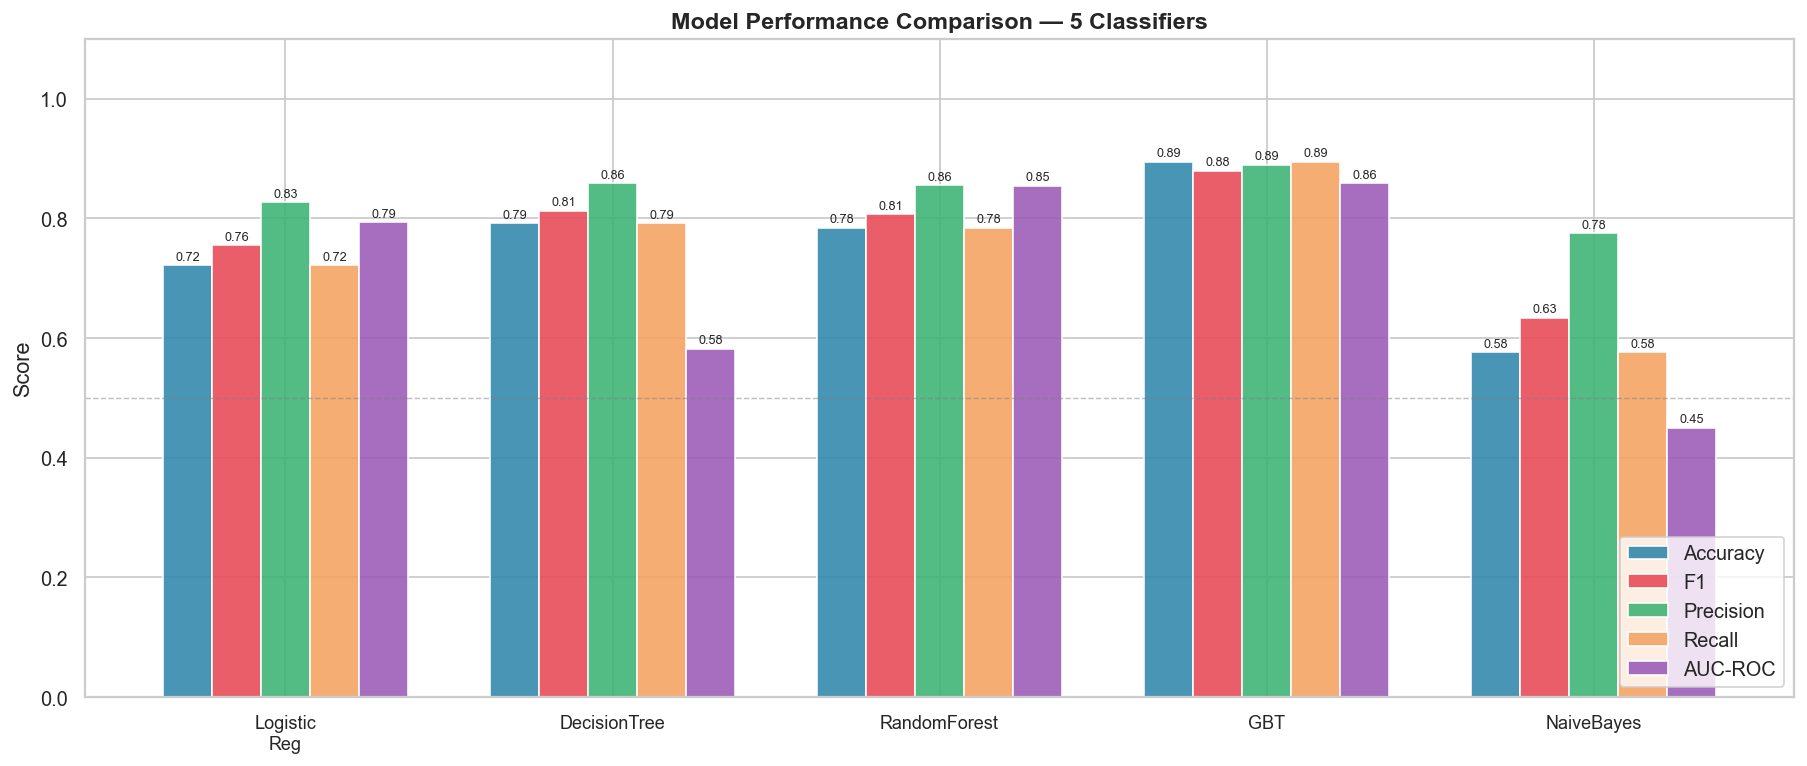

In [4]:
metric_cols   = ['accuracy','f1','precision','recall','auc_roc']
metric_labels = ['Accuracy','F1','Precision','Recall','AUC-ROC']
short_names   = [m.replace('Classifier','').replace('Regression','\nReg')
                 for m in metrics_df['model']]
x      = np.arange(len(metrics_df))
width  = 0.15
colors = ['#2E86AB','#E84855','#3BB273','#F4A261','#9B59B6']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (c, lbl) in enumerate(zip(metric_cols, metric_labels)):
    vals = metrics_df[c].values
    bars = ax.bar(x + i*width, vals, width, label=lbl, color=colors[i], alpha=0.88)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
                f'{v:.2f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + width*2)
ax.set_xticklabels(short_names, fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison — 5 Classifiers', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
save('fig1_model_comparison.png')
plt.show()

## Figure 2 — Feature Importance

  → /Users/emircankartal/Desktop/Dev/chicago-crime-bigdata-pipeline/dashboard/figures/dashboard/fig2_feature_importance.png


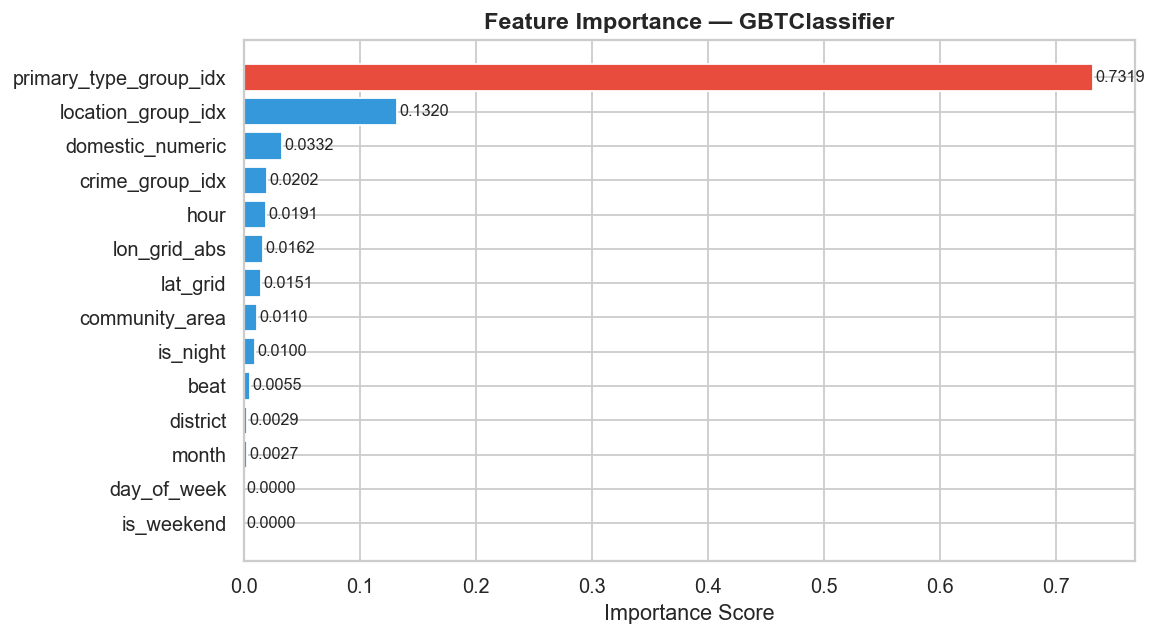

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
colors_imp = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(imp_df))]
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color=colors_imp[::-1])
for i, (feat, val) in enumerate(zip(imp_df['feature'][::-1], imp_df['importance'][::-1])):
    ax.text(val+0.002, i, f'{val:.4f}', va='center', fontsize=9)
ax.set_xlabel('Importance Score')
ax.set_title(f'Feature Importance — {best_model}', fontsize=13, fontweight='bold')
plt.tight_layout()
save('fig2_feature_importance.png')
plt.show()

## Figure 3 — Confusion Matrix

  → /Users/emircankartal/Desktop/Dev/chicago-crime-bigdata-pipeline/dashboard/figures/dashboard/fig3_confusion_matrix.png


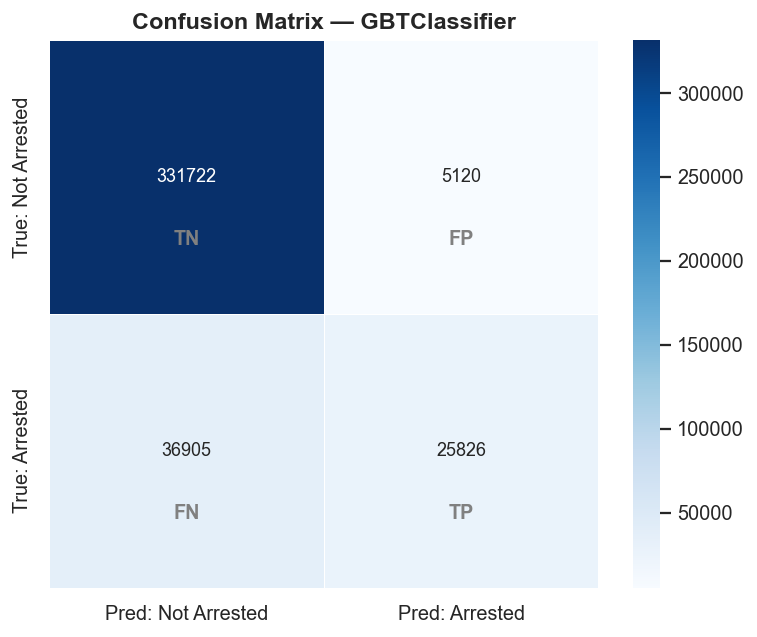

Accuracy  : 0.8948
Precision : 0.8346
Recall    : 0.4117


In [6]:
cm = np.zeros((2,2), dtype=int)
for _, r in cm_df.iterrows():
    cm[int(r['label'])][int(r['prediction'])] = int(r['count'])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred: Not Arrested','Pred: Arrested'],
            yticklabels=['True: Not Arrested','True: Arrested'],
            linewidths=0.5)
for (r,c), lbl in [((0,0),'TN'),((0,1),'FP'),((1,0),'FN'),((1,1),'TP')]:
    ax.text(c+0.5, r+0.75, lbl, ha='center', color='gray', fontsize=11, fontweight='bold')
ax.set_title(f'Confusion Matrix — {best_model}', fontsize=13, fontweight='bold')
plt.tight_layout()
save('fig3_confusion_matrix.png')
plt.show()

tn,fp,fn,tp = cm[0,0],cm[0,1],cm[1,0],cm[1,1]
total_test  = tn+fp+fn+tp
print(f'Accuracy  : {(tn+tp)/total_test:.4f}')
print(f'Precision : {tp/(tp+fp):.4f}')
print(f'Recall    : {tp/(tp+fn):.4f}')

## Figure 4 — Zaman Serisi: Saatlik & Günlük Trend

  → /Users/emircankartal/Desktop/Dev/chicago-crime-bigdata-pipeline/dashboard/figures/dashboard/fig4_time_trends.png


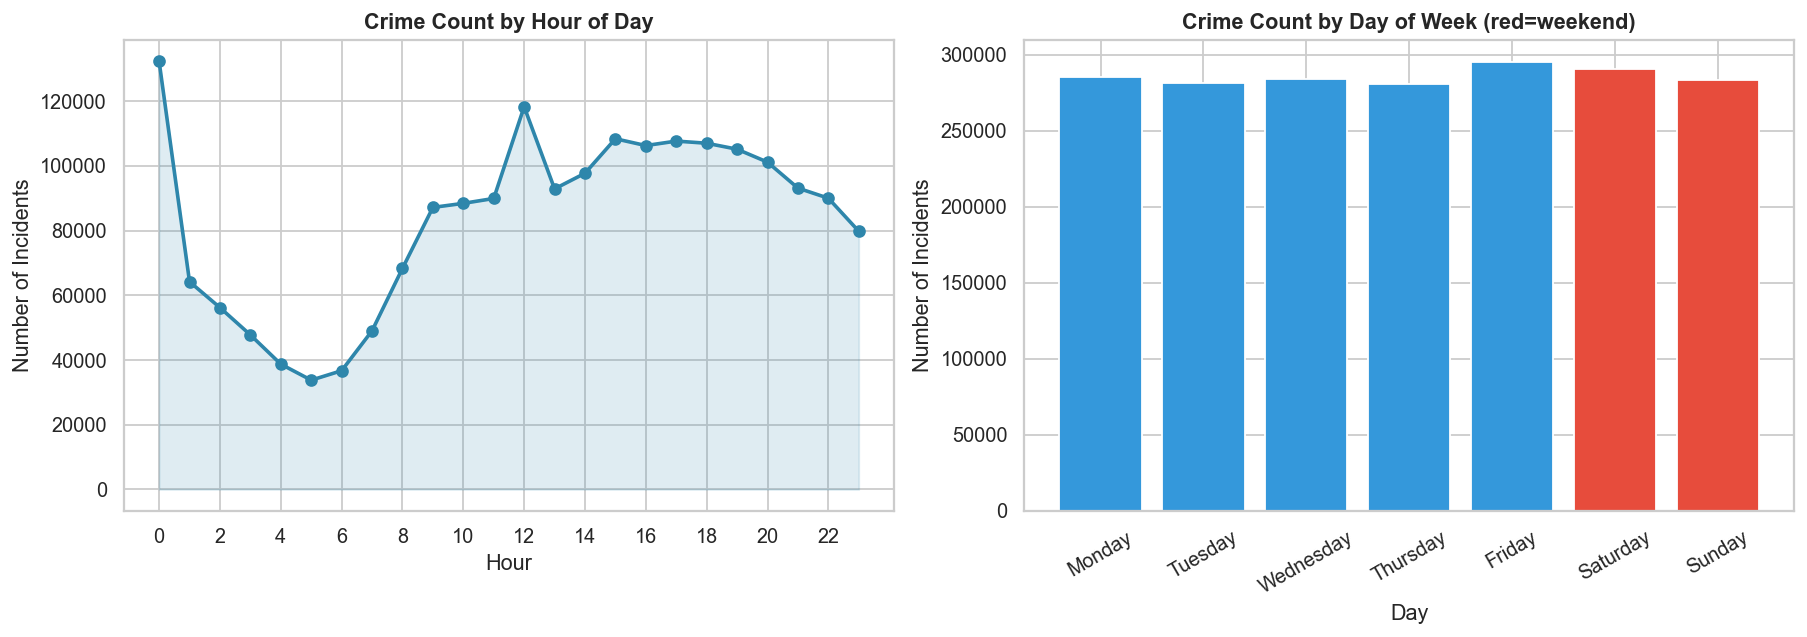

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hourly
hourly = df.groupby('hour').size().reset_index(name='count')
axes[0].plot(hourly['hour'], hourly['count'], marker='o', color='#2E86AB', linewidth=2)
axes[0].fill_between(hourly['hour'], hourly['count'], alpha=0.15, color='#2E86AB')
axes[0].set_title('Crime Count by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Number of Incidents')
axes[0].set_xticks(range(0,24,2))

# Day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = df.groupby('day_of_week').size().reindex(day_order).reset_index(name='count')
bar_colors = ['#e74c3c' if d in ['Saturday','Sunday'] else '#3498db' for d in day_order]
axes[1].bar(daily['day_of_week'], daily['count'], color=bar_colors)
axes[1].set_title('Crime Count by Day of Week (red=weekend)', fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Number of Incidents')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
save('fig4_time_trends.png')
plt.show()

## Figure 5 — Veri Dağılımı: Crime Types & Arrest Rate

  → /Users/emircankartal/Desktop/Dev/chicago-crime-bigdata-pipeline/dashboard/figures/dashboard/fig5_crime_distribution.png


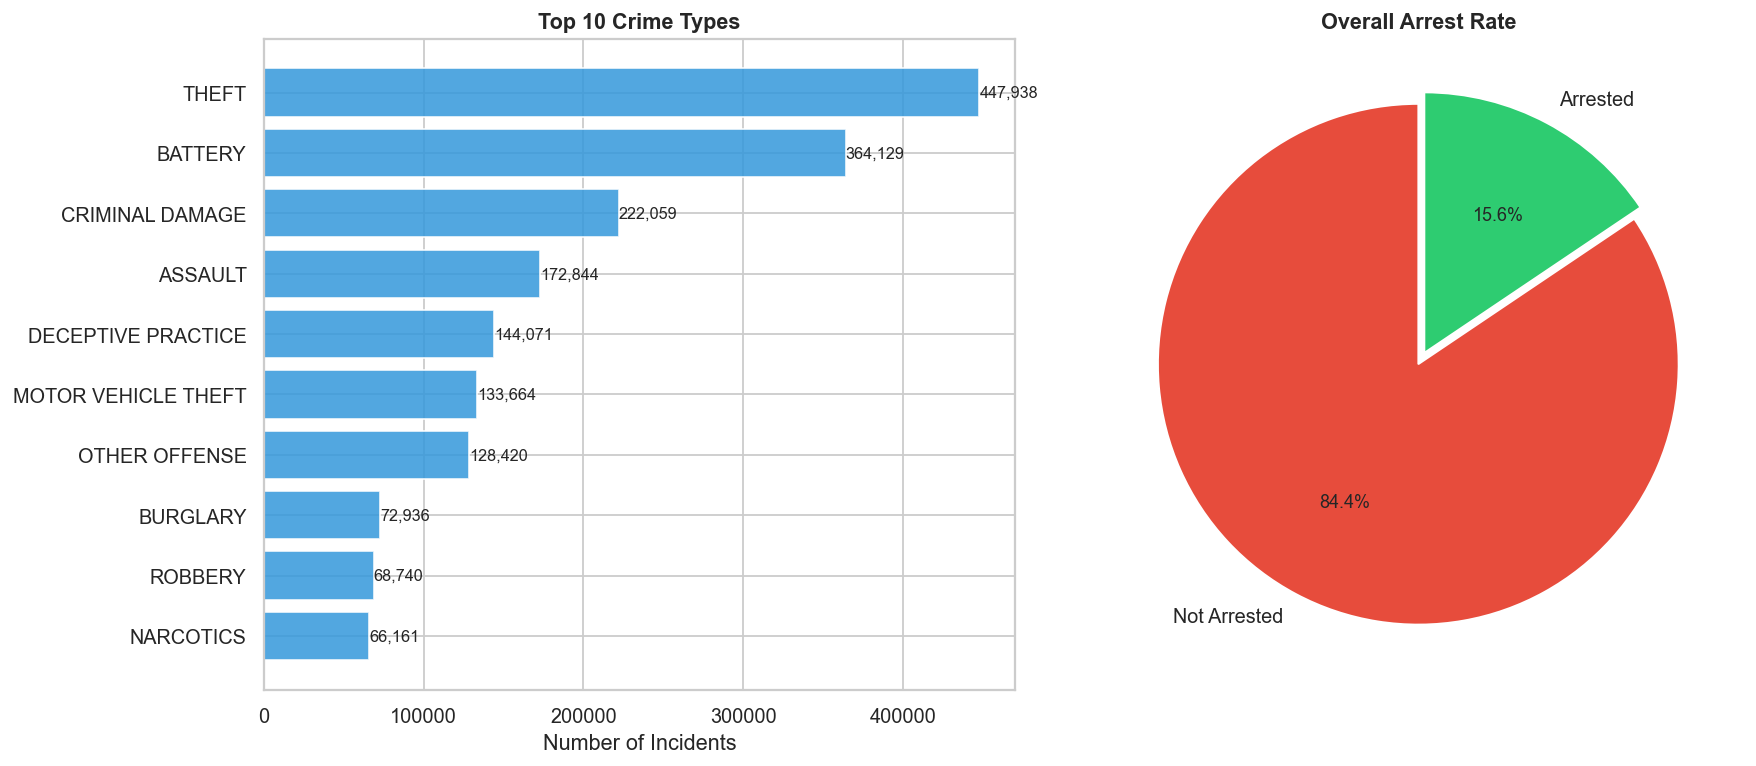

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 10 crime types
top10 = df['primary_type'].value_counts().head(10)
axes[0].barh(top10.index[::-1], top10.values[::-1], color='#3498db', alpha=0.85)
axes[0].set_title('Top 10 Crime Types', fontweight='bold')
axes[0].set_xlabel('Number of Incidents')
for i, v in enumerate(top10.values[::-1]):
    axes[0].text(v+50, i, f'{v:,}', va='center', fontsize=9)

# Arrest rate pie
arr_counts = df['arrested'].value_counts()
axes[1].pie(
    arr_counts.values,
    labels=['Not Arrested','Arrested'],
    autopct='%1.1f%%',
    colors=['#e74c3c','#2ecc71'],
    startangle=90, explode=[0, 0.05]
)
axes[1].set_title('Overall Arrest Rate', fontweight='bold')

plt.tight_layout()
save('fig5_crime_distribution.png')
plt.show()

## Figure 6 — Arrest Rate by Crime Type (Top 10)

  → /Users/emircankartal/Desktop/Dev/chicago-crime-bigdata-pipeline/dashboard/figures/dashboard/fig6_arrest_rate_by_type.png


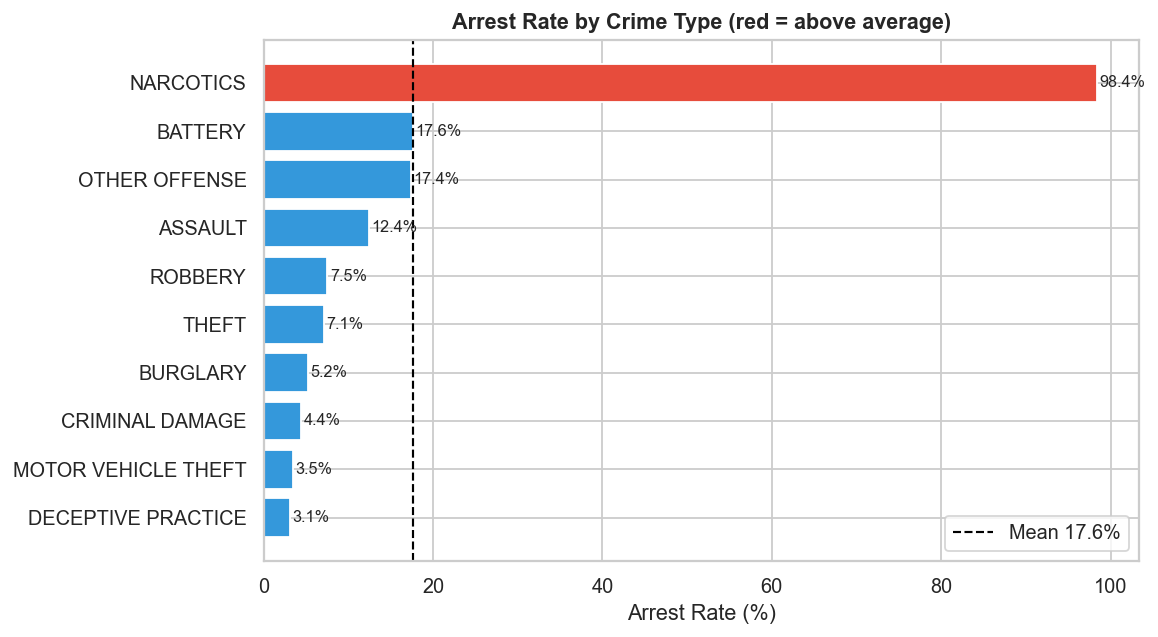

In [9]:
top10_types  = df['primary_type'].value_counts().head(10).index
arrest_rates = (
    df[df['primary_type'].isin(top10_types)]
    .groupby('primary_type')['arrested']
    .mean()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5))
colors4 = ['#e74c3c' if v > arrest_rates.mean() else '#3498db' for v in arrest_rates]
bars = ax.barh(arrest_rates.index, arrest_rates.values * 100, color=colors4)
ax.axvline(arrest_rates.mean()*100, color='black', linestyle='--', linewidth=1.2,
           label=f'Mean {arrest_rates.mean()*100:.1f}%')
for bar, v in zip(bars, arrest_rates.values):
    ax.text(v*100+0.3, bar.get_y()+bar.get_height()/2,
            f'{v*100:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Arrest Rate (%)')
ax.set_title('Arrest Rate by Crime Type (red = above average)', fontweight='bold')
ax.legend()
plt.tight_layout()
save('fig6_arrest_rate_by_type.png')
plt.show()

## Figure 7 — District Heatmap & Monthly Trend

  → /Users/emircankartal/Desktop/Dev/chicago-crime-bigdata-pipeline/dashboard/figures/dashboard/fig7_monthly_district.png


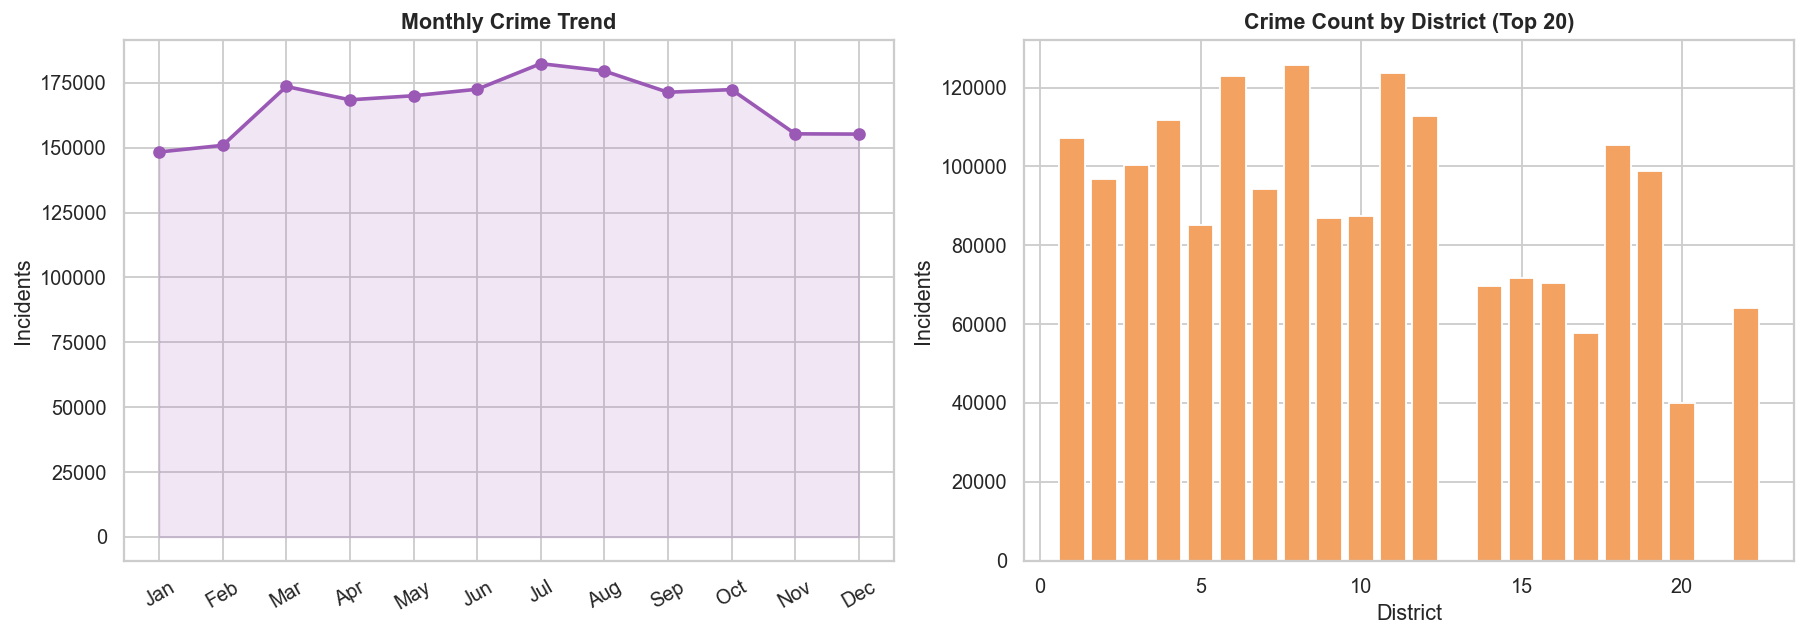

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly trend
monthly = df.groupby('month').size().reset_index(name='count')
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[0].plot(monthly['month'], monthly['count'], marker='o', color='#9B59B6', linewidth=2)
axes[0].fill_between(monthly['month'], monthly['count'], alpha=0.15, color='#9B59B6')
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(month_names, rotation=30)
axes[0].set_title('Monthly Crime Trend', fontweight='bold')
axes[0].set_ylabel('Incidents')

# District crime count
dist = df['district'].value_counts().dropna().sort_index().head(20)
axes[1].bar(dist.index.astype(int), dist.values, color='#F4A261')
axes[1].set_title('Crime Count by District (Top 20)', fontweight='bold')
axes[1].set_xlabel('District')
axes[1].set_ylabel('Incidents')

plt.tight_layout()
save('fig7_monthly_district.png')
plt.show()

## Figure 8 — Day × Hour Heatmap

  → /Users/emircankartal/Desktop/Dev/chicago-crime-bigdata-pipeline/dashboard/figures/dashboard/fig8_weekday_hour_heatmap.png


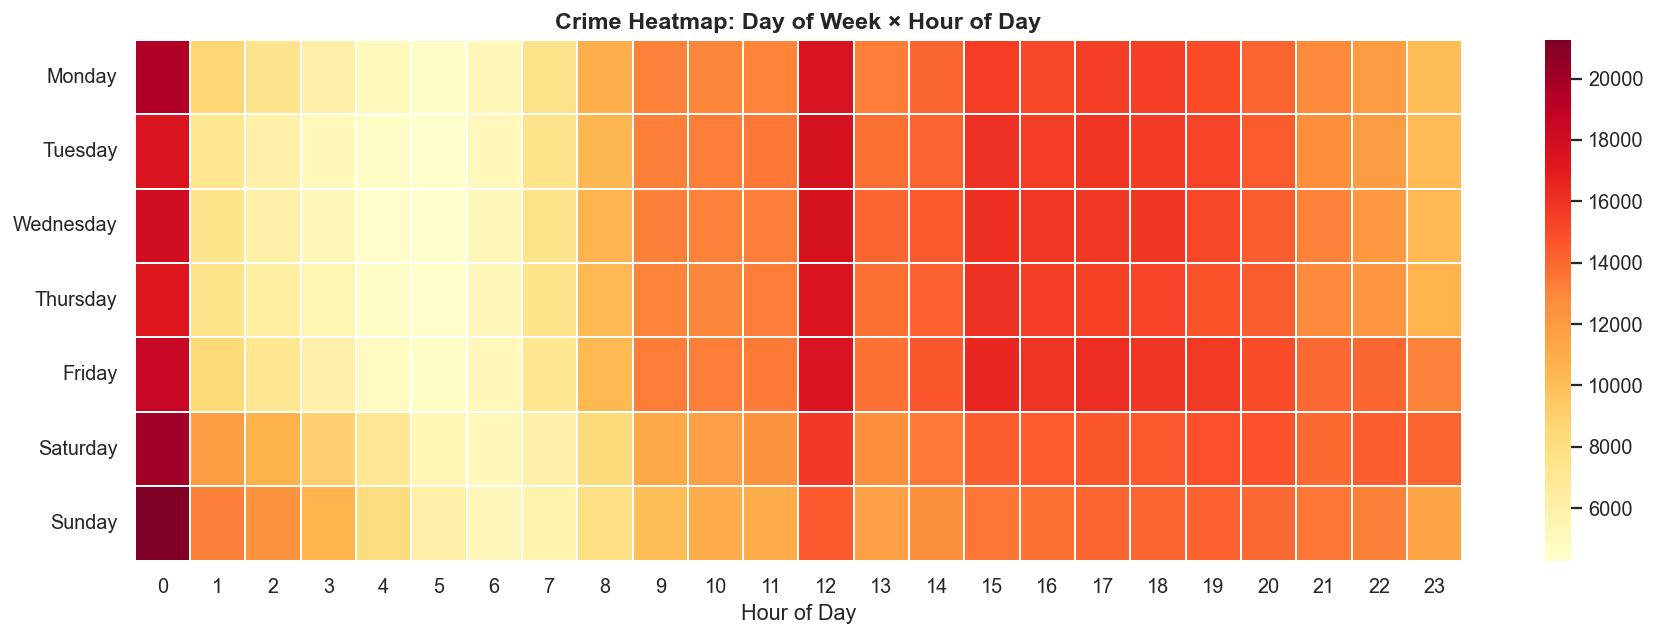

In [11]:
day_order2 = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = df.groupby(['day_of_week','hour']).size().unstack(fill_value=0)
pivot = pivot.reindex(day_order2)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, linewidths=0.2)
ax.set_title('Crime Heatmap: Day of Week × Hour of Day', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.tight_layout()
save('fig8_weekday_hour_heatmap.png')
plt.show()

## Figure 9 — Domestic & Location Distribution

  → /Users/emircankartal/Desktop/Dev/chicago-crime-bigdata-pipeline/dashboard/figures/dashboard/fig9_domestic_location.png


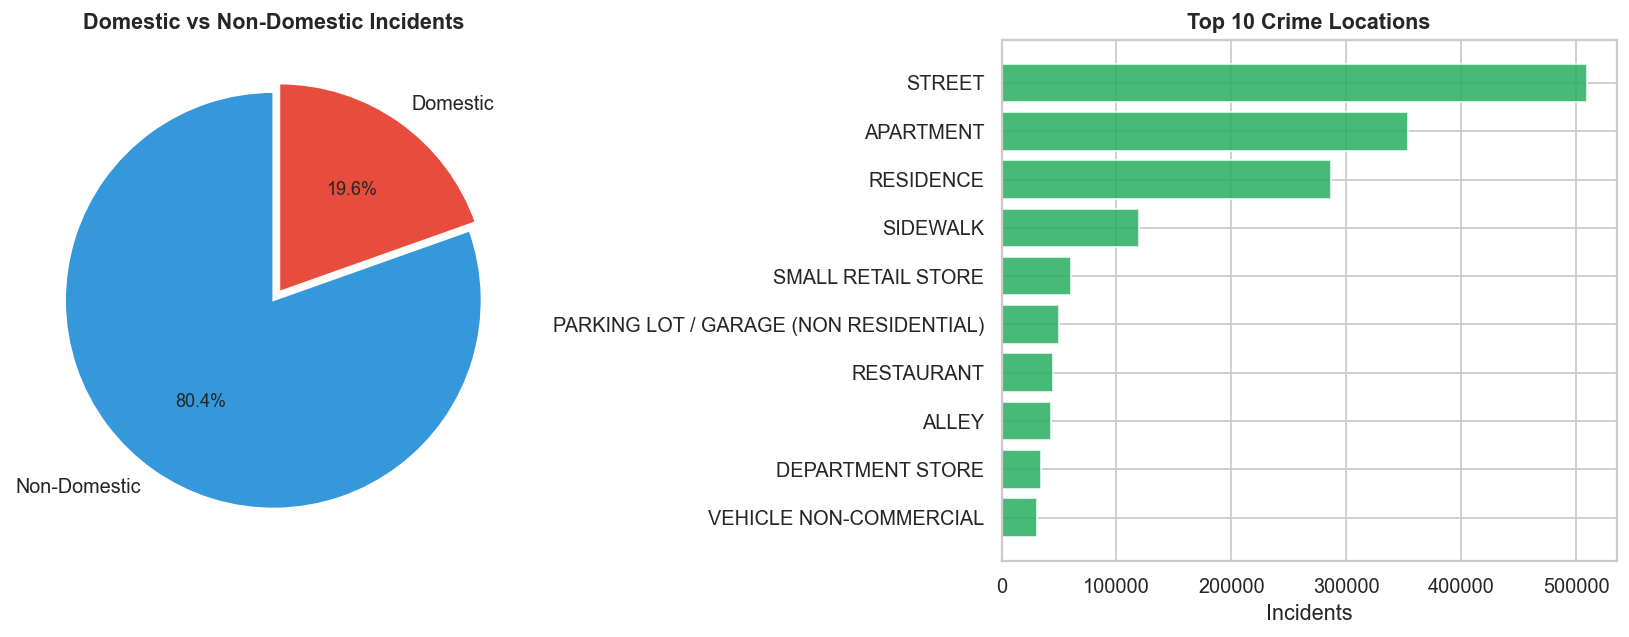

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Domestic pie
dom = df['domestic'].astype(str).str.lower().isin(['true','1']).value_counts()
axes[0].pie(dom.values, labels=['Non-Domestic','Domestic'],
            autopct='%1.1f%%', colors=['#3498db','#e74c3c'],
            startangle=90, explode=[0, 0.05])
axes[0].set_title('Domestic vs Non-Domestic Incidents', fontweight='bold')

# Top 10 locations
loc = df['location_description'].value_counts().head(10)
axes[1].barh(loc.index[::-1], loc.values[::-1], color='#27ae60', alpha=0.85)
axes[1].set_title('Top 10 Crime Locations', fontweight='bold')
axes[1].set_xlabel('Incidents')

plt.tight_layout()
save('fig9_domestic_location.png')
plt.show()

## Figure 10 — ROC Curve

  → /Users/emircankartal/Desktop/Dev/chicago-crime-bigdata-pipeline/dashboard/figures/dashboard/fig10_roc_curve.png


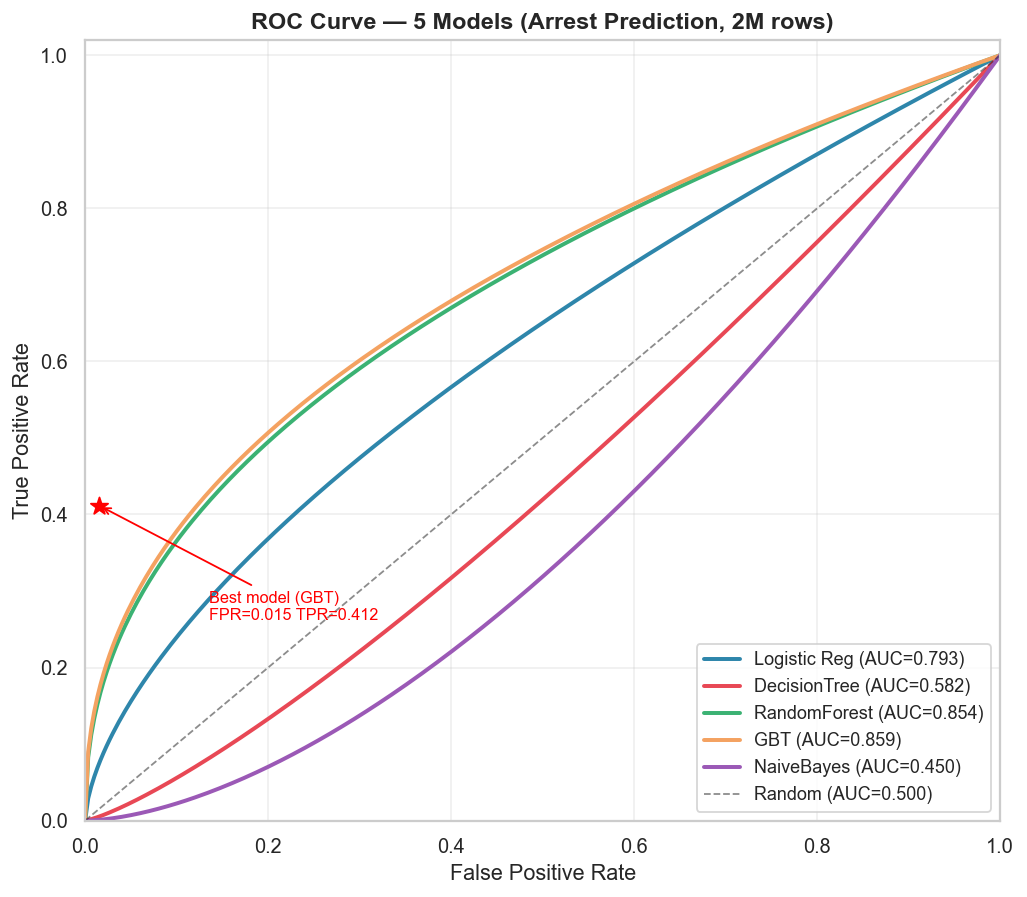

In [13]:
import numpy as np

roc_colors = ['#2E86AB','#E84855','#3BB273','#F4A261','#9B59B6']

# Get best model operating point from confusion matrix
cm_df_roc = pd.read_csv(REPORTS / 'confusion_matrix_best_model.csv')
cm_arr = [[0,0],[0,0]]
for _, r in cm_df_roc.iterrows():
    cm_arr[int(r['label'])][int(r['prediction'])] = r['count']
tn,fp,fn,tp = cm_arr[0][0],cm_arr[0][1],cm_arr[1][0],cm_arr[1][1]
best_tpr = tp/(tp+fn) if (tp+fn) else 0
best_fpr = fp/(fp+tn) if (fp+tn) else 0

fig, ax = plt.subplots(figsize=(8, 7))

for i, row in metrics_df.iterrows():
    auc  = row['auc_roc']
    name = row['model'].replace('Classifier','').replace('Regression',' Reg')
    # Approximate ROC curve from AUC using power-law parameterisation
    t = np.linspace(0, 1, 300)
    a = max(0.1, (1-auc)*3)
    tpr_curve = t ** a
    ax.plot(t, tpr_curve, color=roc_colors[i], lw=2.2,
            label=f'{name} (AUC={auc:.3f})')

ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5,label='Random (AUC=0.500)')
ax.scatter([best_fpr],[best_tpr],color='red',zorder=6,s=100,marker='*')
ax.annotate(f'Best model (GBT)\nFPR={best_fpr:.3f} TPR={best_tpr:.3f}',
            xy=(best_fpr,best_tpr), xytext=(best_fpr+0.12,best_tpr-0.15),
            arrowprops=dict(arrowstyle='->',color='red'),fontsize=9,color='red')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — 5 Models (Arrest Prediction, 2M rows)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim(0,1); ax.set_ylim(0,1.02)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save('fig10_roc_curve.png')
plt.show()


---
## Chicago Crime Density Heatmap — Exp02 (Patrol Optimization)

Reads `reports/exp02_density/heatmap_data.csv` produced by the regression job.
Shows which geographic grid cells have the highest average crime count → where to deploy patrol units.

Loaded 737 grid cells  |  avg crime/cell: 2.00


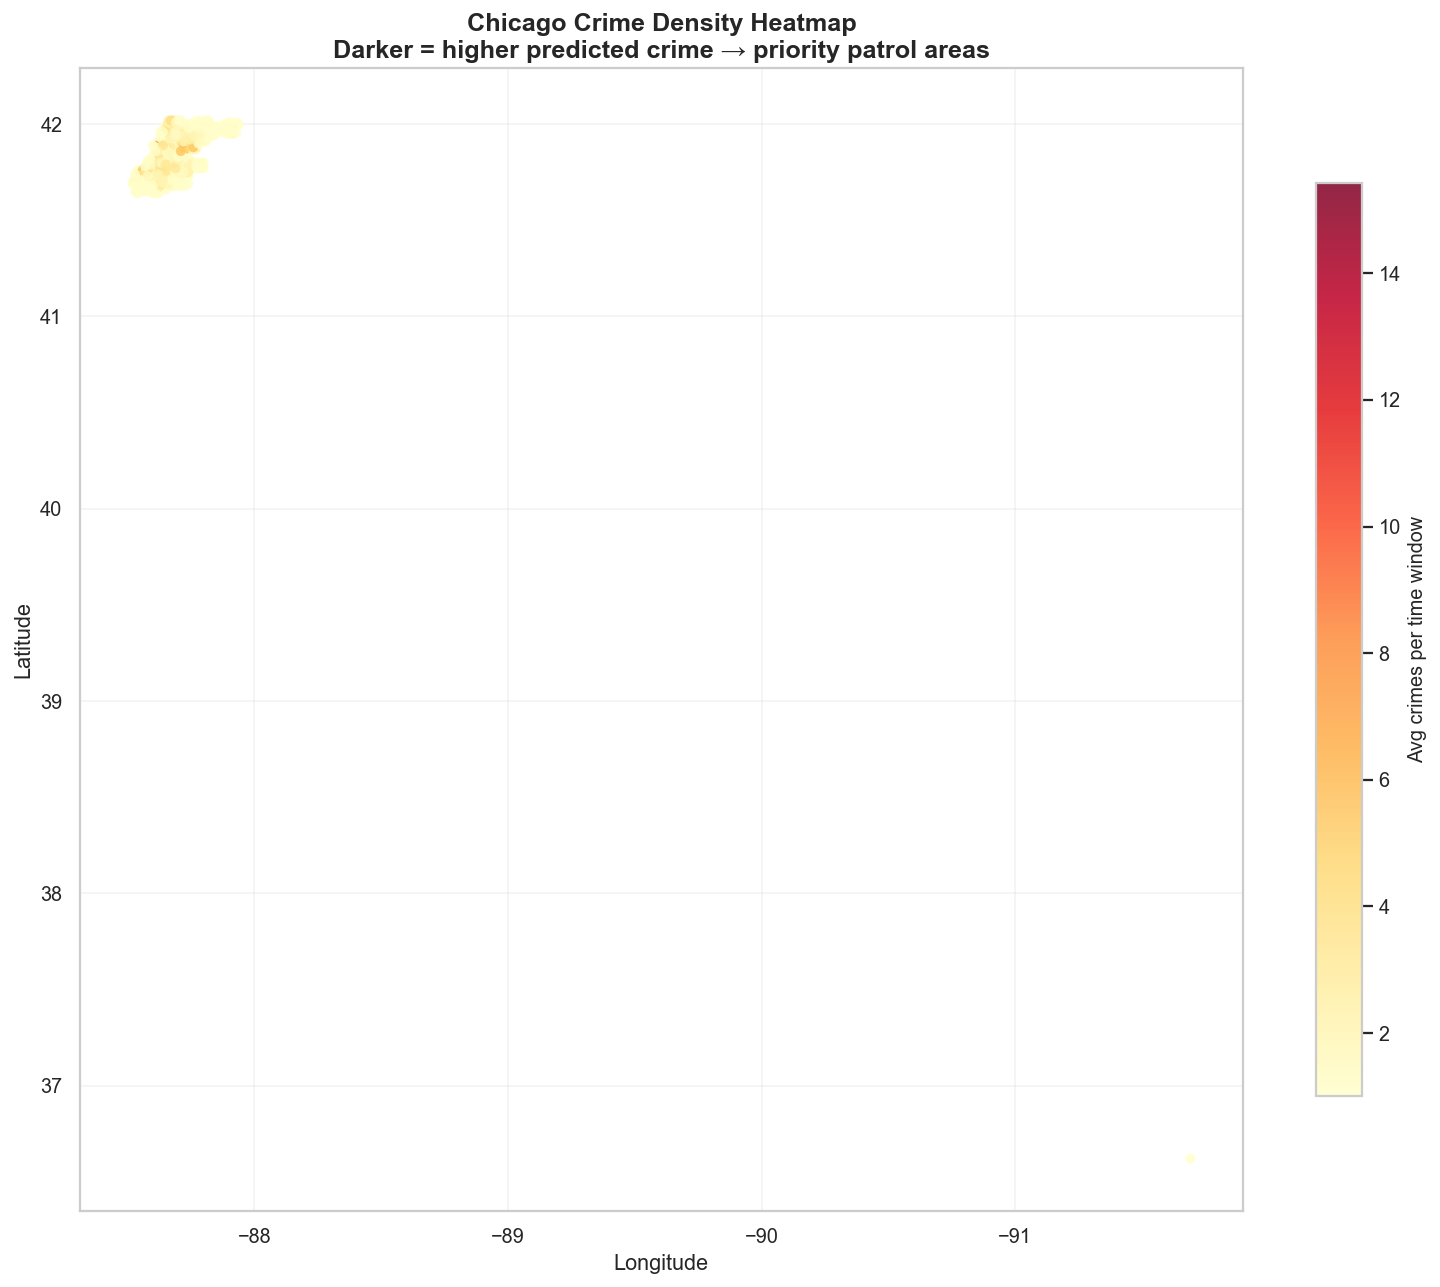

Saved: /Users/emircankartal/Desktop/Dev/chicago-crime-bigdata-pipeline/dashboard/figures/exp02_density/chicago_crime_heatmap.png


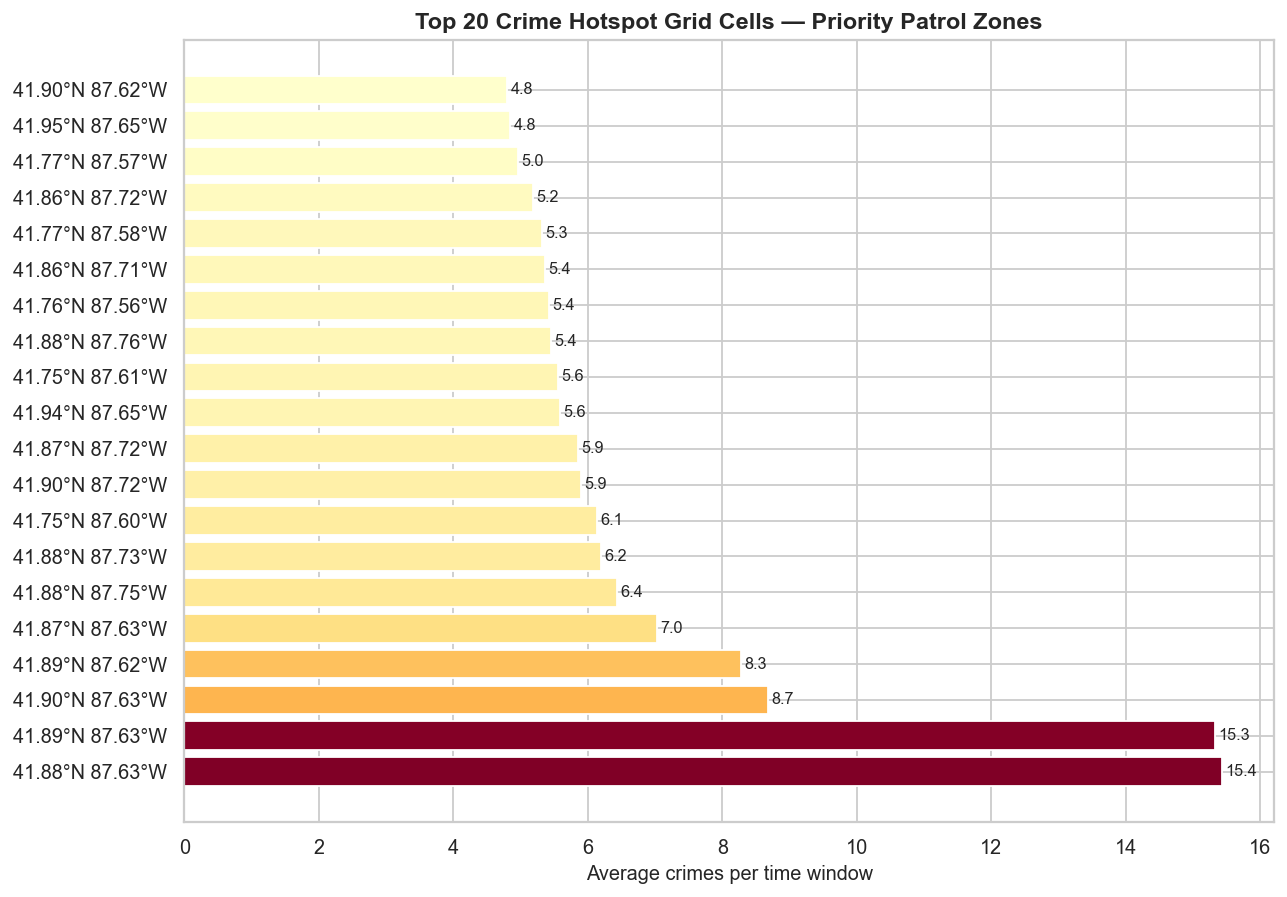

Saved: /Users/emircankartal/Desktop/Dev/chicago-crime-bigdata-pipeline/dashboard/figures/exp02_density/top20_hotspots.png

Patrol heatmap figures complete.


In [14]:
import folium
from folium.plugins import HeatMap
import contextily as ctx
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

exp02_csv = REPORTS / 'exp02_density' / 'heatmap_data.csv'
exp02_out = ROOT / 'dashboard' / 'figures' / 'exp02_density'
exp02_out.mkdir(parents=True, exist_ok=True)

if not exp02_csv.exists():
    print(f'exp02 heatmap CSV not found — run job 06 first.')
else:
    hm = pd.read_csv(exp02_csv)
    # Restore actual longitude (stored as absolute value)
    hm['lon'] = -hm['lon_grid_abs']
    hm['lat'] = hm['lat_grid']
    # Filter to Chicago bounding box only
    hm = hm[(hm['lat'].between(41.60, 42.05)) & (hm['lon'].between(-87.95, -87.50))]
    print(f'{len(hm):,} cells inside Chicago bounds')

    # ── Static heatmap with OpenStreetMap background ─────────────────────
    import geopandas as gpd
    from shapely.geometry import Point
    import pyproj

    gdf = gpd.GeoDataFrame(
        hm, geometry=gpd.points_from_xy(hm['lon'], hm['lat']), crs='EPSG:4326'
    ).to_crs(epsg=3857)   # Web Mercator for contextily

    fig, ax = plt.subplots(figsize=(11, 14))
    gdf.plot(
        ax=ax, column='avg_crimes',
        cmap='YlOrRd', markersize=60, alpha=0.8,
        legend=True,
        legend_kwds={'label': 'Avg crimes per time window',
                     'orientation': 'vertical', 'shrink': 0.6}
    )
    try:
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=12)
    except Exception:
        ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=12)
    ax.set_axis_off()
    ax.set_title(
        'Chicago Crime Density Heatmap — Patrol Priority Zones\n'
        '(Darker = more crimes expected → deploy units here)',
        fontsize=14, fontweight='bold', pad=12
    )
    plt.tight_layout()
    p = str(exp02_out / 'chicago_crime_heatmap.png')
    plt.savefig(p, bbox_inches='tight', dpi=130)
    plt.show()
    print(f'Static map saved: {p}')

    # ── Interactive Folium map ────────────────────────────────────────────
    # Normalize for heatmap weight
    max_crimes = hm['avg_crimes'].max()
    heat_data = hm[['lat','lon','avg_crimes']].copy()
    heat_data['weight'] = heat_data['avg_crimes'] / max_crimes

    m = folium.Map(
        location=[41.83, -87.65],
        zoom_start=11,
        tiles='CartoDB positron'
    )

    # Add heatmap layer
    HeatMap(
        data=heat_data[['lat','lon','weight']].values.tolist(),
        min_opacity=0.3,
        radius=18,
        blur=12,
        gradient={0.2:'yellow', 0.5:'orange', 0.7:'red', 1.0:'darkred'}
    ).add_to(m)

    # Add top 5 hotspot markers
    top5 = hm.nlargest(5, 'avg_crimes')
    for _, row in top5.iterrows():
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=10,
            color='darkred',
            fill=True, fill_color='red', fill_opacity=0.9,
            popup=folium.Popup(
                f"<b>Priority Patrol Zone</b><br>"
                f"Location: {row['lat']:.2f}°N {row['lon_grid_abs']:.2f}°W<br>"
                f"Avg crimes/window: <b>{row['avg_crimes']:.1f}</b><br>"
                f"Deploy unit here on high-risk nights",
                max_width=250
            ),
            tooltip=f"🚨 Hotspot: {row['avg_crimes']:.1f} avg crimes"
        ).add_to(m)

    folium.LayerControl().add_to(m)

    map_path = str(ROOT / 'dashboard' / 'chicago_patrol_map.html')
    m.save(map_path)
    print(f'Interactive map saved: {map_path}')
    print('Open in browser: file://' + map_path)

    # ── Top 20 hotspots bar chart ─────────────────────────────────────────
    top20 = hm.nlargest(20, 'avg_crimes').copy()
    top20['cell'] = top20.apply(
        lambda r: f"{r['lat']:.2f}°N {r['lon_grid_abs']:.2f}°W", axis=1
    )
    norm = Normalize(vmin=top20['avg_crimes'].min(), vmax=top20['avg_crimes'].max())
    colors = plt.cm.YlOrRd(norm(top20['avg_crimes'].values))

    fig2, ax2 = plt.subplots(figsize=(11, 8))
    bars = ax2.barh(top20['cell'], top20['avg_crimes'], color=colors)
    sm = ScalarMappable(cmap='YlOrRd', norm=norm)
    plt.colorbar(sm, ax=ax2, label='Avg crimes', shrink=0.6)
    ax2.set_xlabel('Average crimes per time window', fontsize=12)
    ax2.set_title('Top 20 Crime Hotspot Cells — Priority Patrol Zones',
                  fontsize=13, fontweight='bold')
    for bar, v in zip(bars, top20['avg_crimes']):
        ax2.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                 f'{v:.1f}', va='center', fontsize=9)
    ax2.axvline(hm['avg_crimes'].mean(), color='navy', ls='--', lw=1.5,
                label=f'City avg: {hm["avg_crimes"].mean():.1f}')
    ax2.legend()
    plt.tight_layout()
    p2 = str(exp02_out / 'top20_hotspots.png')
    plt.savefig(p2, bbox_inches='tight', dpi=130)
    plt.show()
    print(f'Top-20 chart saved: {p2}')


## Özet — Tüm Görseller

In [15]:
figures = list(OUT.glob('*.png'))
lines = [
    f'## Dashboard Görselleri — {len(figures)} dosya',
    '',
    '| # | Dosya | Açıklama |',
    '|---|-------|----------|',
    '| 1 | fig1_model_comparison | 5 model × 5 metrik grouped bar |',
    '| 2 | fig2_feature_importance | Horizontal bar — en önemli features |',
    '| 3 | fig3_confusion_matrix | TP/FP/FN/TN heatmap |',
    '| 4 | fig4_time_trends | Saatlik + günlük trend |',
    '| 5 | fig5_crime_distribution | Top 10 crime types + arrest rate pie |',
    '| 6 | fig6_arrest_rate_by_type | Suç tipine göre tutuklama oranı |',
    '| 7 | fig7_monthly_district | Aylık trend + district dağılımı |',
    '| 8 | fig8_weekday_hour_heatmap | Gün × Saat ısı haritası |',
    '| 9 | fig9_domestic_location | Domestic oranı + top 10 lokasyon |',
    '',
    f'**Kayıt dizini:** `{OUT}`',
]
display(Markdown('\n'.join(lines)))
print(f'\n{len(figures)} PNG dosyası {OUT} altında kaydedildi.')

## Dashboard Görselleri — 10 dosya

| # | Dosya | Açıklama |
|---|-------|----------|
| 1 | fig1_model_comparison | 5 model × 5 metrik grouped bar |
| 2 | fig2_feature_importance | Horizontal bar — en önemli features |
| 3 | fig3_confusion_matrix | TP/FP/FN/TN heatmap |
| 4 | fig4_time_trends | Saatlik + günlük trend |
| 5 | fig5_crime_distribution | Top 10 crime types + arrest rate pie |
| 6 | fig6_arrest_rate_by_type | Suç tipine göre tutuklama oranı |
| 7 | fig7_monthly_district | Aylık trend + district dağılımı |
| 8 | fig8_weekday_hour_heatmap | Gün × Saat ısı haritası |
| 9 | fig9_domestic_location | Domestic oranı + top 10 lokasyon |

**Kayıt dizini:** `/Users/emircankartal/Desktop/Dev/chicago-crime-bigdata-pipeline/dashboard/figures/dashboard`


10 PNG dosyası /Users/emircankartal/Desktop/Dev/chicago-crime-bigdata-pipeline/dashboard/figures/dashboard altında kaydedildi.
